# Predicción del Valor de Mercado de Jugadores de Fútbol

**Autores:** Carlos Alberto Mazo Gil, Manuel Villegas Michel  

**Objetivo:** Predecir `market_value_in_eur` a partir de variables transaccionales del historial de transferencias (Transfermarkt / Kaggle), sin depender de estadísticas de rendimiento individual.

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn shap

  Using cached shap-0.51.0-cp314-cp314-win_amd64.whl.metadata (26 kB)
  Using cached numba-0.65.0-cp314-cp314-win_amd64.whl.metadata (3.0 kB)
Using cached shap-0.51.0-cp314-cp314-win_amd64.whl (559 kB)
Using cached numba-0.65.0-cp314-cp314-win_amd64.whl (2.8 MB)

   ---------------------------------------- 0/2 [numba]
   ---------------------------------------- 0/2 [numba]
   ---------------------------------------- 0/2 [numba]
   ---------------------------------------- 0/2 [numba]
   ---------------------------------------- 0/2 [numba]
   ---------------------------------------- 0/2 [numba]
   ---------------------------------------- 0/2 [numba]
   ---------------------------------------- 0/2 [numba]
   ---------------------------------------- 0/2 [numba]
   ---------------------------------------- 0/2 [numba]
   ---------------------------------------- 0/2 [numba]
   ---------------------------------------- 0/2 [numba]
   ---------------------------------------- 0/2 [numba]
   -----

In [3]:
!pip install shap==0.44.1

  Using cached shap-0.44.1.tar.gz (1.1 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached slicer-0.0.7-py3-none-any.whl.metadata (3.7 kB)
Using cached slicer-0.0.7-py3-none-any.whl (14 kB)
Failed to build shap


  error: subprocess-exited-with-error
  
  exit code: 1
  
  [217 lines of output]
  C:\Users\mvale\AppData\Local\Temp\pip-build-env-ay3542tb\overlay\Lib\site-packages\setuptools\config\_apply_pyprojecttoml.py:82: SetuptoolsDeprecationWarning: `project.license` as a TOML table is deprecated
  !!
  
          ********************************************************************************
          Please use a simple string containing a SPDX expression for `project.license`. You can also use `project.license-files`. (Both options available on setuptools>=77.0.0).
  
          By 2027-Feb-18, you need to update your project and remove deprecated calls
          or your builds will no longer be supported.
  
          See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
          ********************************************************************************
  
  !!
    corresp(dist, value, root_dir)
  C:\Users\mvale\AppData\Local\Temp\pip-build

In [4]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

import shap
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
print("Librerías cargadas correctamente.")

C:\Users\mvale\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías cargadas correctamente.


## 1. Carga de Datos
Dataset fuente: [Kaggle - player-scores / transfers.csv](https://www.kaggle.com/datasets/davidcariboo/player-scores)  
Tamaño esperado: ~157,186 registros totales | ~96,338 con target válido.

In [5]:
import requests, gzip, io, os

archivos = ["transfers", "players", "appearances", "clubs"]

for nombre in archivos:
    url = f"https://pub-e682421888d945d684bcae8890b0ec20.r2.dev/data/{nombre}.csv.gz"
    print(f"Descargando {nombre}.csv ...")
    r = requests.get(url)
    with gzip.open(io.BytesIO(r.content)) as f:
        contenido = f.read()
    with open(f"{nombre}.csv", "wb") as f:
        f.write(contenido)
    print(f"✓ {nombre}.csv guardado ({len(contenido)//1024} KB)")

print("\nArchivos disponibles:", os.listdir("."))

Descargando transfers.csv ...
✓ transfers.csv guardado (13028 KB)
Descargando players.csv ...
✓ players.csv guardado (16334 KB)
Descargando appearances.csv ...
✓ appearances.csv guardado (143129 KB)
Descargando clubs.csv ...
✓ clubs.csv guardado (179 KB)

Archivos disponibles: ['.ipynb_checkpoints', 'appearances.csv', 'clubs.csv', 'Football Transfer 2.ipynb', 'Football Transfer.ipynb', 'players.csv', 'transfers.csv']


In [17]:
import pandas as pd

df = pd.read_csv("transfers.csv")
print(f"Shape original: {df.shape}")
df.head()

Shape original: (157186, 10)


,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name
0,467994,2030-06-30,25/26,5621,749,Reggiana,FC Empoli,0.0,700000.0,Luca Belardinelli
1,784335,2027-07-18,27/28,6505,6502,Gimcheon Sangmu,Jeonbuk Hyundai,0.0,500000.0,Jun-soo Byeon
2,402135,2027-07-04,27/28,6505,515,Gimcheon Sangmu,Without Club,NaN,350000.0,Jun-su Ahn
3,716435,2027-07-04,27/28,6505,30925,Gimcheon Sangmu,Gwangju FC,0.0,325000.0,Kang-hyun Lee
4,803933,2027-06-30,26/27,4467,14,TSV Hartberg,Austria Vienna,0.0,300000.0,Luca Pazourek


## 2. Inspección Inicial del Dataset

In [7]:
print("=== Tipos de datos ===")
print(df.dtypes)
print(f"\n=== Valores nulos por columna ===")
print(df.isnull().sum())
print(f"\n=== Estadísticas descriptivas ===")
df.describe()

=== Tipos de datos ===
player_id                int64
transfer_date              str
transfer_season            str
from_club_id             int64
to_club_id               int64
from_club_name             str
to_club_name               str
transfer_fee           float64
market_value_in_eur    float64
player_name                str
dtype: object

=== Valores nulos por columna ===
player_id                  0
transfer_date              0
transfer_season            0
from_club_id               0
to_club_id                 0
from_club_name             0
to_club_name               0
transfer_fee           54833
market_value_in_eur    60848
player_name                0
dtype: int64

=== Estadísticas descriptivas ===


,player_id,from_club_id,to_club_id,transfer_fee,market_value_in_eur
count,1.571860e+05,157186.000000,157186.000000,1.023530e+05,9.633800e+04
mean,5.021871e+05,20156.261461,15612.525040,8.023499e+05,1.882969e+06
std,3.128459e+05,27177.836622,23659.217653,4.441027e+06,4.913449e+06
min,3.333000e+03,1.000000,1.000000,0.000000e+00,1.000000e+04
25%,2.540030e+05,1047.000000,800.000000,0.000000e+00,2.000000e+05
50%,4.488135e+05,8817.000000,4961.000000,0.000000e+00,5.000000e+05
75%,6.982352e+05,28870.000000,18852.000000,0.000000e+00,1.500000e+06
max,1.529719e+06,140641.000000,140573.000000,2.220000e+08,1.800000e+08


## 3. Análisis Exploratorio de Datos (EDA)

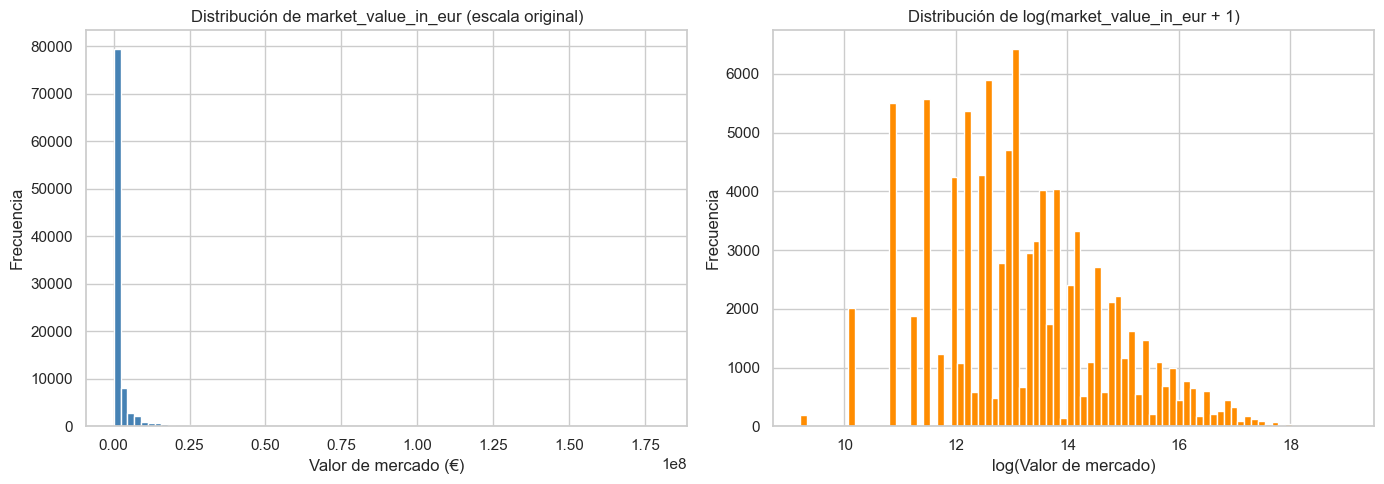

Rango original: €10,000 — €180,000,000
Mediana: €500,000 | Media: €1,882,969


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Escala original
axes[0].hist(df["market_value_in_eur"].dropna(), bins=80, color="steelblue", edgecolor="white")
axes[0].set_title("Distribución de market_value_in_eur (escala original)")
axes[0].set_xlabel("Valor de mercado (€)")
axes[0].set_ylabel("Frecuencia")

# Escala logarítmica
log_vals = np.log1p(df["market_value_in_eur"].dropna())
axes[1].hist(log_vals, bins=80, color="darkorange", edgecolor="white")
axes[1].set_title("Distribución de log(market_value_in_eur + 1)")
axes[1].set_xlabel("log(Valor de mercado)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

print(f"Rango original: €{df['market_value_in_eur'].min():,.0f} — €{df['market_value_in_eur'].max():,.0f}")
print(f"Mediana: €{df['market_value_in_eur'].median():,.0f} | Media: €{df['market_value_in_eur'].mean():,.0f}")

=== is_free_transfer (derivado de transfer_fee) ===
is_free_transfer
1    140673
0     16513
Name: count, dtype: int64


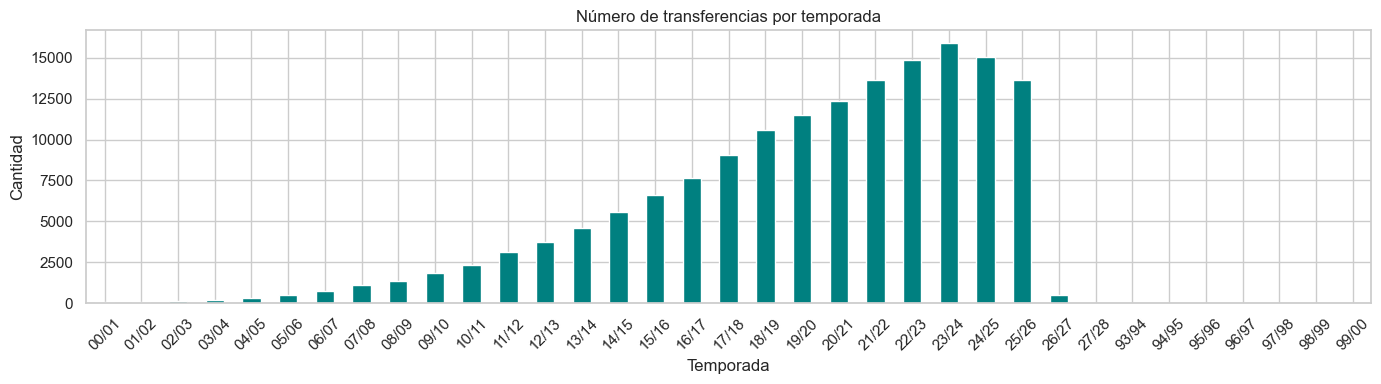

In [9]:
# Transferencias gratuitas: fee == 0 o nulo
df["is_free_transfer"] = ((df["transfer_fee"] == 0) | (df["transfer_fee"].isna())).astype(int)

print("=== is_free_transfer (derivado de transfer_fee) ===")
print(df["is_free_transfer"].value_counts(dropna=False))

# Transferencias por temporada
plt.figure(figsize=(14, 4))
df["transfer_season"].value_counts().sort_index().plot(kind="bar", color="teal")
plt.title("Número de transferencias por temporada")
plt.xlabel("Temporada")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

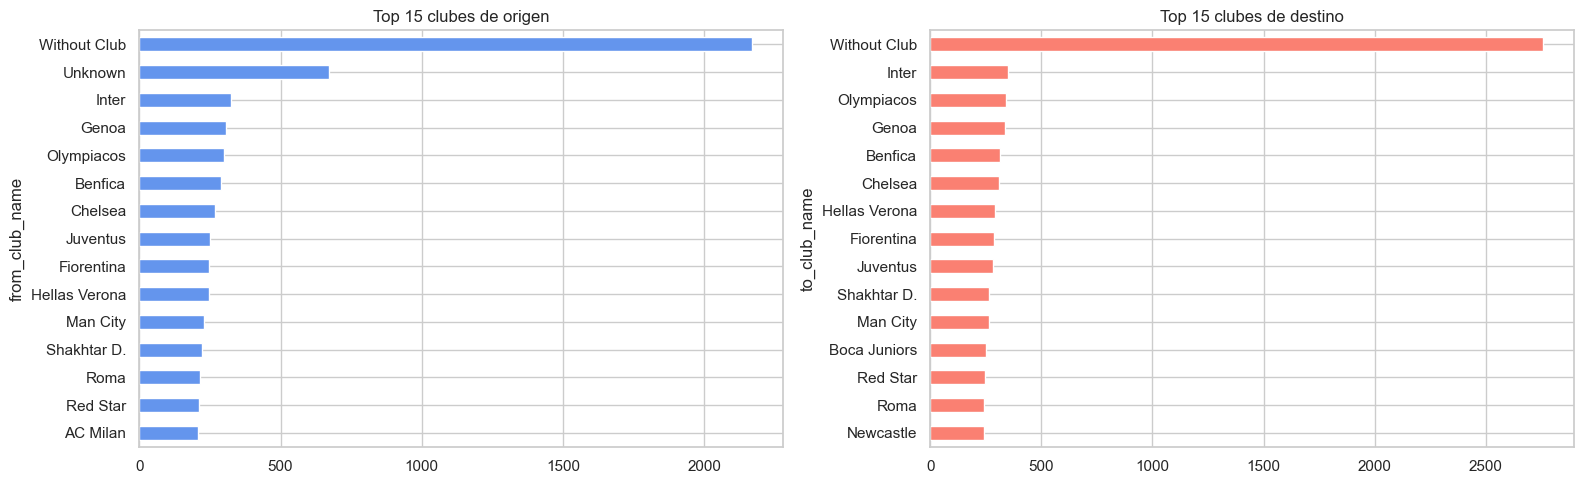

In [10]:
top_n = 15

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df["from_club_name"].value_counts().head(top_n).plot(
    kind="barh", ax=axes[0], color="cornflowerblue")
axes[0].set_title(f"Top {top_n} clubes de origen")
axes[0].invert_yaxis()

df["to_club_name"].value_counts().head(top_n).plot(
    kind="barh", ax=axes[1], color="salmon")
axes[1].set_title(f"Top {top_n} clubes de destino")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 4. Preprocesamiento y Feature Engineering
Pasos:
1. Filtrar registros con `market_value_in_eur` válido (no nulo, > 0)
2. Extraer features temporales de `transfer_date` y `transfer_season`
3. Label Encoding de clubes de origen y destino
4. Flag de transferencia gratuita como variable binaria
5. Transformación logarítmica del target

In [11]:
# 1. Filtrar target válido
df_clean = df[df["market_value_in_eur"].notna() & (df["market_value_in_eur"] > 0)].copy()
print(f"Registros con target válido: {len(df_clean):,}")

# 2. Derivar is_free_transfer desde transfer_fee
df_clean["is_free_transfer"] = ((df_clean["transfer_fee"] == 0) | (df_clean["transfer_fee"].isna())).astype(int)

# 3. Features temporales
df_clean["transfer_date"] = pd.to_datetime(df_clean["transfer_date"], errors="coerce")
df_clean["transfer_year"]  = df_clean["transfer_date"].dt.year
df_clean["transfer_month"] = df_clean["transfer_date"].dt.month

# Extraer año de inicio de temporada (e.g. "2021/2022" → 2021)
df_clean["season_start"] = (
    df_clean["transfer_season"]
    .str.split("/")
    .str[0]
    .str.strip()
    .astype(float)
    .apply(lambda x: x + 2000 if x < 100 else x)
)

# 4. Label Encoding de clubes
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_clean["club_origin_encoded"]      = le.fit_transform(df_clean["from_club_name"].fillna("Unknown"))
df_clean["club_destination_encoded"] = le.fit_transform(df_clean["to_club_name"].fillna("Unknown"))

# 5. Transformación logarítmica del target
df_clean["log_market_value"] = np.log1p(df_clean["market_value_in_eur"])

print(df_clean[[
    "market_value_in_eur", "log_market_value", "transfer_year",
    "transfer_month", "season_start", "is_free_transfer",
    "club_origin_encoded", "club_destination_encoded"
]].describe())

Registros con target válido: 96,338
       market_value_in_eur  log_market_value  transfer_year  transfer_month  \
count         9.633800e+04      96338.000000   96338.000000    96338.000000   
mean          1.882969e+06         13.198530    2020.888538        5.683002   
std           4.913449e+06          1.512280       3.889530        3.070780   
min           1.000000e+04          9.210440    2005.000000        1.000000   
25%           2.000000e+05         12.206078    2019.000000        2.000000   
50%           5.000000e+05         13.122365    2022.000000        7.000000   
75%           1.500000e+06         14.220976    2024.000000        7.000000   
max           1.800000e+08         19.008467    2030.000000       12.000000   

       season_start  is_free_transfer  club_origin_encoded  \
count  96338.000000      96338.000000         96338.000000   
mean    2020.426789          0.839233          3132.342513   
std        3.871012          0.367318          1777.053238   
min 

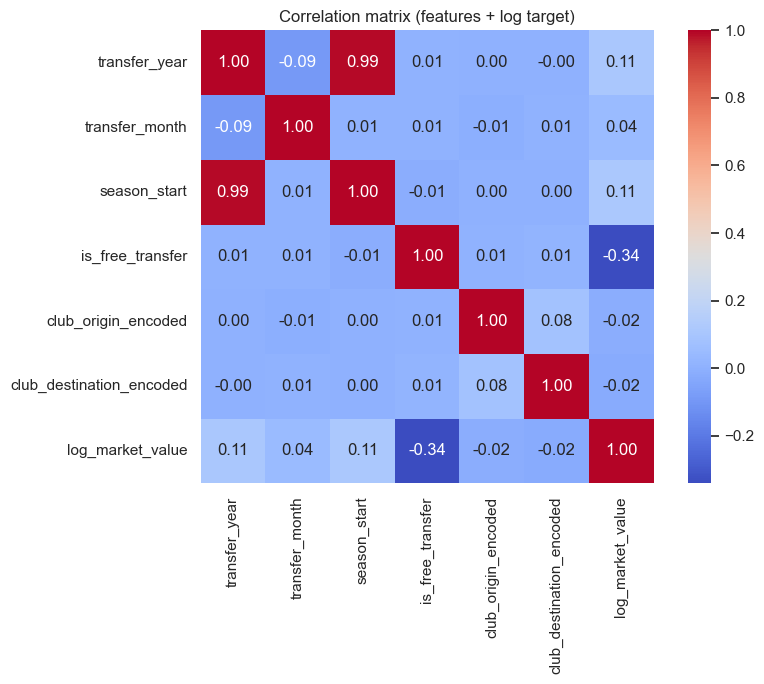

In [13]:
features_corr = ["transfer_year", "transfer_month", "season_start",
                 "is_free_transfer", "club_origin_encoded",
                 "club_destination_encoded", "log_market_value"]

corr_matrix = df_clean[features_corr].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation matrix (features + log target)")
plt.tight_layout()
plt.show()

## 5. División de Datos

Se usa una estrategia temporal para evitar data leakage:
- **Train:** Temporadas anteriores a 2023/24
- **Validation:** Temporada 2023/2024 — ajuste de hiperparámetros
- **Test:** Temporada 2024/2025 — evaluación final únicamente

In [19]:
# Feature engineering adicional
# 1. Frecuencia de cada club como vendedor (proxy de "club grande")
freq_origin = df_clean["from_club_name"].value_counts().to_dict()
freq_dest   = df_clean["to_club_name"].value_counts().to_dict()

df_clean["club_origin_freq"]      = df_clean["from_club_name"].map(freq_origin).fillna(0)
df_clean["club_destination_freq"] = df_clean["to_club_name"].map(freq_dest).fillna(0)

# 2. Valor mediano de transferencias del club de origen (target encoding con train solamente)
median_origin = train.groupby("from_club_name")["market_value_in_eur"].median().to_dict()
median_dest   = train.groupby("to_club_name")["market_value_in_eur"].median().to_dict()

global_median = df_clean["market_value_in_eur"].median()

df_clean["origin_median_value"] = (
    df_clean["from_club_name"].map(median_origin).fillna(global_median)
)
df_clean["dest_median_value"] = (
    df_clean["to_club_name"].map(median_dest).fillna(global_median)
)

# 3. Log de transfer_fee (cuando existe)
df_clean["log_transfer_fee"] = np.log1p(df_clean["transfer_fee"].fillna(0))

print("Features nuevas agregadas.")
print(df_clean[["club_origin_freq", "club_destination_freq",
                "origin_median_value", "dest_median_value",
                "log_transfer_fee"]].describe())

Features nuevas agregadas.
       club_origin_freq  club_destination_freq  origin_median_value  \
count      96338.000000           96338.000000         9.633800e+04   
mean         103.477091             143.415786         1.024052e+06   
std          219.375126             344.745104         1.341609e+06   
min            1.000000               1.000000         1.000000e+04   
25%           25.000000              33.000000         3.000000e+05   
50%           63.000000              81.000000         5.000000e+05   
75%          115.000000             139.000000         1.200000e+06   
max         1682.000000            2302.000000         1.200000e+07   

       dest_median_value  log_transfer_fee  
count       9.633800e+04      96338.000000  
mean        1.046380e+06          2.296659  
std         1.465388e+06          5.288788  
min         1.000000e+04          0.000000  
25%         3.000000e+05          0.000000  
50%         5.000000e+05          0.000000  
75%         1.0000

In [21]:
# Máscaras temporales
mask_test  = df_clean["transfer_season"] == "24/25"
mask_val   = df_clean["transfer_season"] == "23/24"
mask_train = ~mask_test & ~mask_val

TARGET_LOG  = "log_market_value"
TARGET_ORIG = "market_value_in_eur"

train = df_clean[mask_train]
val   = df_clean[mask_val]
test  = df_clean[mask_test]

X_train = train[FEATURES]
y_train = train[TARGET_LOG]

X_val      = val[FEATURES]
y_val_log  = val[TARGET_LOG]
y_val_orig = val[TARGET_ORIG]

X_test      = test[FEATURES]
y_test_log  = test[TARGET_LOG]
y_test_orig = test[TARGET_ORIG]

print(f"Train      : {len(X_train):,} registros")
print(f"Validation : {len(X_val):,} registros")
print(f"Test       : {len(X_test):,} registros")

Train      : 72,363 registros
Validation : 11,962 registros
Test       : 12,013 registros


In [22]:
# Actualizar FEATURES con las nuevas variables
FEATURES = [
    "transfer_year", "transfer_month", "season_start",
    "is_free_transfer", "club_origin_encoded", "club_destination_encoded",
    "club_origin_freq", "club_destination_freq",
    "origin_median_value", "dest_median_value",
    "log_transfer_fee"
]

# Reconstruir splits con nuevas features
X_train = train[FEATURES]
X_val   = val[FEATURES]
X_test  = test[FEATURES]

# Re-imputar con el imputer ya entrenado — reentrenar con nuevas columnas
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=FEATURES)
X_val   = pd.DataFrame(imputer.transform(X_val),       columns=FEATURES)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=FEATURES)

# Resetear índices
y_train     = train[TARGET_LOG].reset_index(drop=True)
y_val_log   = val[TARGET_LOG].reset_index(drop=True)
y_val_orig  = val[TARGET_ORIG].reset_index(drop=True)
y_test_log  = test[TARGET_LOG].reset_index(drop=True)
y_test_orig = test[TARGET_ORIG].reset_index(drop=True)

print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")

X_train: (72363, 11) | X_val: (11962, 11) | X_test: (12013, 11)


In [23]:
def evaluate_model(name, model, split="val"):
    """
    Evalúa el modelo en validación o test.
    split: 'val' o 'test'
    """
    if split == "val":
        X, y_log, y_orig = X_val, y_val_log, y_val_orig
    else:
        X, y_log, y_orig = X_test, y_test_log, y_test_orig

    y_pred_log  = model.predict(X)
    y_pred_orig = np.expm1(y_pred_log)

    log_rmse = np.sqrt(mean_squared_error(y_log, y_pred_log))
    r2       = r2_score(y_log, y_pred_log)
    mae_orig = mean_absolute_error(y_orig, y_pred_orig)

    print(f"\n{'='*45}")
    print(f"Modelo : {name}  |  Split: {split.upper()}")
    print(f"log-RMSE : {log_rmse:.4f}")
    print(f"R²       : {r2:.4f}")
    print(f"MAE (€)  : {mae_orig:,.0f}")
    print(f"{'='*45}")

    return {"model": name, "split": split,
            "log_RMSE": log_rmse, "R2": r2, "MAE_eur": mae_orig}

## 6. Entrenamiento y Evaluación de Modelos

### 6.1 Regresión Lineal (baseline)
Modelo interpretable que establece la cota mínima de desempeño.

In [25]:
lr = LinearRegression()
lr.fit(X_train, y_train)
res_lr_val = evaluate_model("Regresión Lineal", lr, split="val")


Modelo : Regresión Lineal  |  Split: VAL
log-RMSE : 1.0493
R²       : 0.5036
MAE (€)  : 2,000,491


### 6.2 Decision Tree Regressor
Se busca el mejor `max_depth` evaluando en el conjunto de validación.

In [26]:
best_r2, best_depth, best_dt = -np.inf, None, None

for depth in [4, 6, 8, 10, 12]:
    dt_candidate = DecisionTreeRegressor(
        max_depth=depth, min_samples_leaf=20, random_state=42
    )
    dt_candidate.fit(X_train, y_train)
    r2_val = r2_score(y_val_log, dt_candidate.predict(X_val))
    print(f"  max_depth={depth}  →  R²_val={r2_val:.4f}")
    if r2_val > best_r2:
        best_r2, best_depth, best_dt = r2_val, depth, dt_candidate

print(f"\nMejor max_depth: {best_depth}  (R²_val={best_r2:.4f})")
dt = best_dt
res_dt_val = evaluate_model("Decision Tree", dt, split="val")

  max_depth=4  →  R²_val=0.5558
  max_depth=6  →  R²_val=0.5984
  max_depth=8  →  R²_val=0.6100
  max_depth=10  →  R²_val=0.6135
  max_depth=12  →  R²_val=0.6141

Mejor max_depth: 12  (R²_val=0.6141)

Modelo : Decision Tree  |  Split: VAL
log-RMSE : 0.9252
R²       : 0.6141
MAE (€)  : 1,005,762


### 6.3 Random Forest Regressor
Se buscan los mejores `n_estimators` y `max_depth` evaluando en validación.
El ensamble de múltiples árboles reduce el sobreajuste y mejora la generalización.

In [27]:
best_r2_rf, best_params, best_rf = -np.inf, {}, None

for n_est in [100, 200]:
    for depth in [8, 12, 16]:
        rf_candidate = RandomForestRegressor(
            n_estimators=n_est, max_depth=depth,
            min_samples_leaf=10, n_jobs=-1, random_state=42
        )
        rf_candidate.fit(X_train, y_train)
        r2_val = r2_score(y_val_log, rf_candidate.predict(X_val))
        print(f"  n_est={n_est}  max_depth={depth}  →  R²_val={r2_val:.4f}")
        if r2_val > best_r2_rf:
            best_r2_rf  = r2_val
            best_params = {"n_estimators": n_est, "max_depth": depth}
            best_rf     = rf_candidate

print(f"\nMejores parámetros RF: {best_params}  (R²_val={best_r2_rf:.4f})")
rf = best_rf
res_rf_val = evaluate_model("Random Forest", rf, split="val")

  n_est=100  max_depth=8  →  R²_val=0.6241
  n_est=100  max_depth=12  →  R²_val=0.6359
  n_est=100  max_depth=16  →  R²_val=0.6381
  n_est=200  max_depth=8  →  R²_val=0.6243
  n_est=200  max_depth=12  →  R²_val=0.6364
  n_est=200  max_depth=16  →  R²_val=0.6384

Mejores parámetros RF: {'n_estimators': 200, 'max_depth': 16}  (R²_val=0.6384)

Modelo : Random Forest  |  Split: VAL
log-RMSE : 0.8956
R²       : 0.6384
MAE (€)  : 952,136


## 7. Comparación de Modelos


Modelo : Regresión Lineal  |  Split: TEST
log-RMSE : 1.0114
R²       : 0.5064
MAE (€)  : 1,925,813

Modelo : Decision Tree  |  Split: TEST
log-RMSE : 0.9103
R²       : 0.6002
MAE (€)  : 1,089,380

Modelo : Random Forest  |  Split: TEST
log-RMSE : 0.8777
R²       : 0.6283
MAE (€)  : 1,029,552

=== Validación ===
           model split  log_RMSE       R2      MAE_eur
Regresión Lineal   val  1.049281 0.503624 2.000491e+06
   Decision Tree   val  0.925156 0.614115 1.005762e+06
   Random Forest   val  0.895552 0.638416 9.521358e+05

=== Test ===
           model split  log_RMSE       R2      MAE_eur
Regresión Lineal  test  1.011432 0.506386 1.925813e+06
   Decision Tree  test  0.910253 0.600204 1.089380e+06
   Random Forest  test  0.877736 0.628257 1.029552e+06


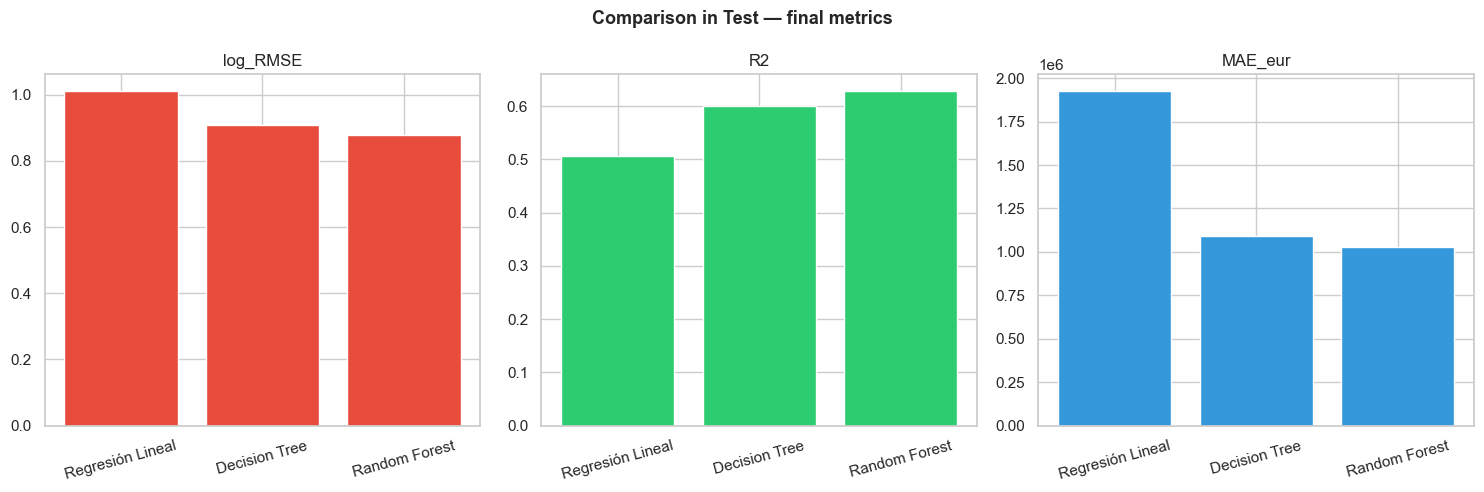

In [28]:
# Evaluación final en TEST
res_lr_test = evaluate_model("Regresión Lineal", lr, split="test")
res_dt_test = evaluate_model("Decision Tree",    dt, split="test")
res_rf_test = evaluate_model("Random Forest",    rf, split="test")

# Tabla comparativa
results_df = pd.DataFrame([
    res_lr_val, res_dt_val, res_rf_val,
    res_lr_test, res_dt_test, res_rf_test
])

print("\n=== Validación ===")
print(results_df[results_df["split"] == "val"].to_string(index=False))
print("\n=== Test ===")
print(results_df[results_df["split"] == "test"].to_string(index=False))

# Gráfico comparativo en Test
test_results = results_df[results_df["split"] == "test"].reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ["log_RMSE", "R2", "MAE_eur"]
colors  = ["#e74c3c", "#2ecc71", "#3498db"]

for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(test_results["model"], test_results[metric], color=color)
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Comparison in Test — final metrics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Análisis de Predicciones vs. Valores Reales
Comparación visual en escala logarítmica para los tres modelos evaluados en Test.

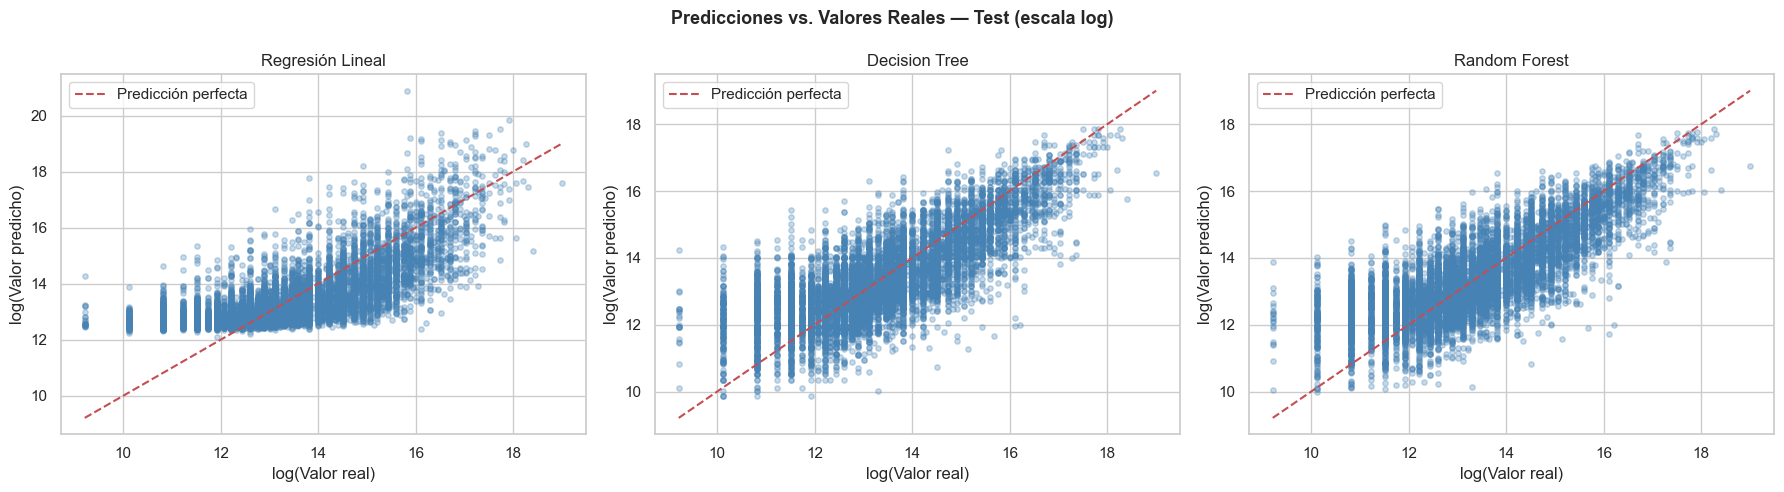

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos = [
    ("Regresión Lineal", lr),
    ("Decision Tree",    dt),
    ("Random Forest",    rf)
]

for ax, (name, model) in zip(axes, modelos):
    y_pred = model.predict(X_test)
    ax.scatter(y_test_log, y_pred, alpha=0.3, s=15, color="steelblue")
    lims = [y_test_log.min(), y_test_log.max()]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Predicción perfecta")
    ax.set_xlabel("log(Valor real)")
    ax.set_ylabel("log(Valor predicho)")
    ax.set_title(name)
    ax.legend()

plt.suptitle("Predicciones vs. Valores Reales — Test (escala log)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

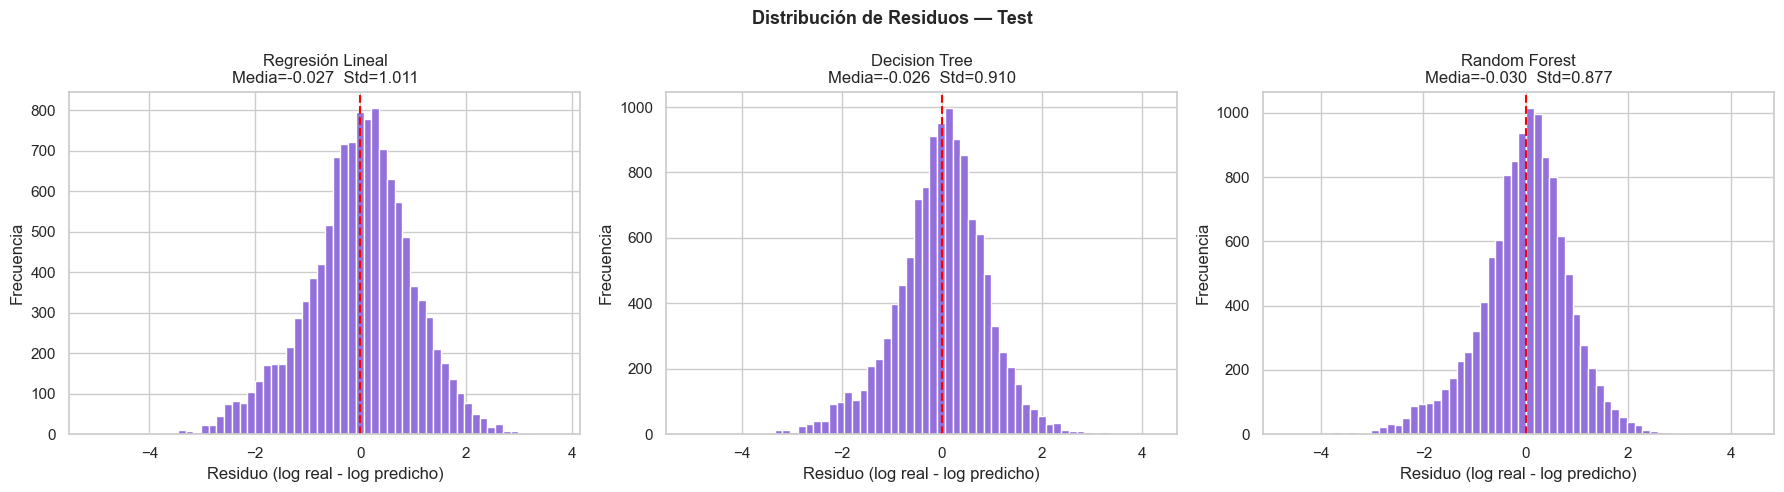

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, modelos):
    y_pred  = model.predict(X_test)
    residuos = y_test_log - y_pred
    ax.hist(residuos, bins=60, color="mediumpurple", edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_xlabel("Residuo (log real - log predicho)")
    ax.set_ylabel("Frecuencia")
    ax.set_title(f"{name}\nMedia={residuos.mean():.3f}  Std={residuos.std():.3f}")

plt.suptitle("Distribución de Residuos — Test", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Importancia de Features
### 9.1 Random Forest — Importancia por Gini

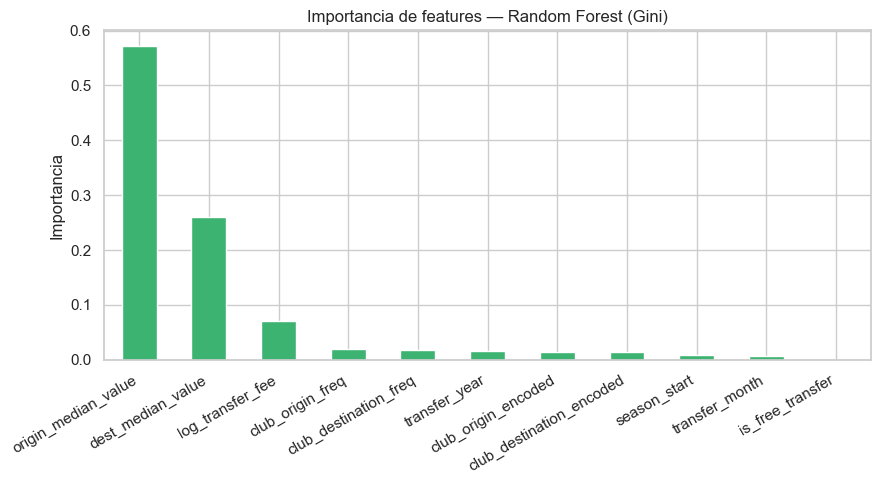


Ranking de features:
  1. origin_median_value: 0.5716
  2. dest_median_value: 0.2601
  3. log_transfer_fee: 0.0699
  4. club_origin_freq: 0.0188
  5. club_destination_freq: 0.0187
  6. transfer_year: 0.0155
  7. club_origin_encoded: 0.0146
  8. club_destination_encoded: 0.0142
  9. season_start: 0.0090
  10. transfer_month: 0.0072
  11. is_free_transfer: 0.0002


In [31]:
importances = pd.Series(
    rf.feature_importances_, index=FEATURES
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importances.plot(kind="bar", color="mediumseagreen", edgecolor="white")
plt.title("Importancia de features — Random Forest (Gini)")
plt.ylabel("Importancia")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("\nRanking de features:")
for i, (feat, imp) in enumerate(importances.items(), 1):
    print(f"  {i}. {feat}: {imp:.4f}")

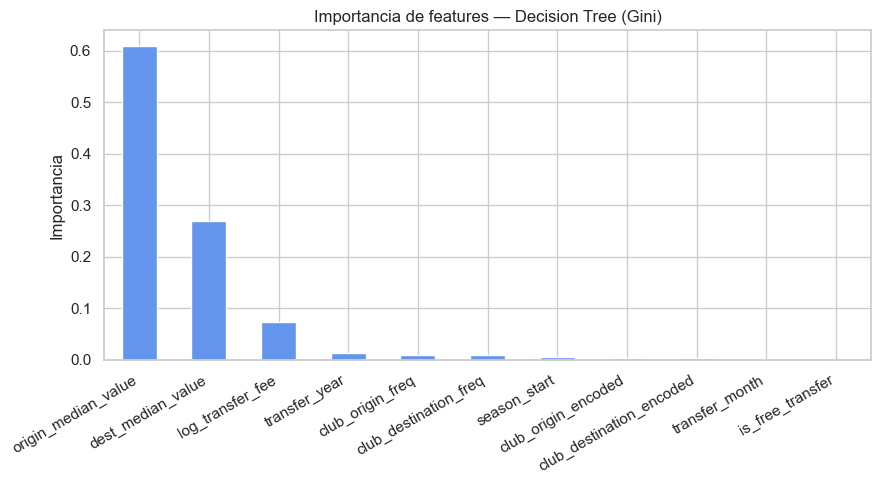

In [32]:
importances_dt = pd.Series(
    dt.feature_importances_, index=FEATURES
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importances_dt.plot(kind="bar", color="cornflowerblue", edgecolor="white")
plt.title("Importancia de features — Decision Tree (Gini)")
plt.ylabel("Importancia")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 9.2 Análisis SHAP — Random Forest
SHAP (SHapley Additive exPlanations) permite interpretar la contribución de cada feature
a nivel individual, yendo más allá de la importancia global por Gini.

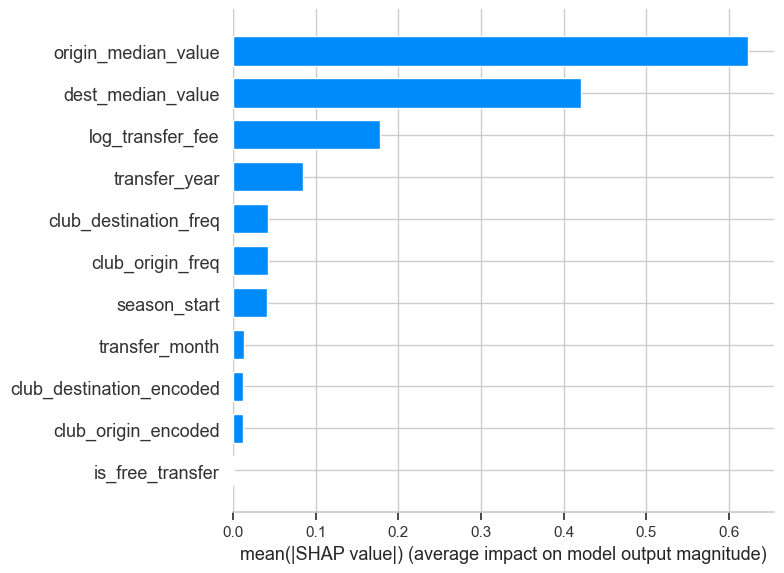

In [33]:
# Usar una muestra para que sea más rápido
X_test_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_sample)

# Gráfico de barras — importancia global SHAP
shap.summary_plot(
    shap_values, X_test_sample,
    feature_names=FEATURES,
    plot_type="bar",
    show=True
)

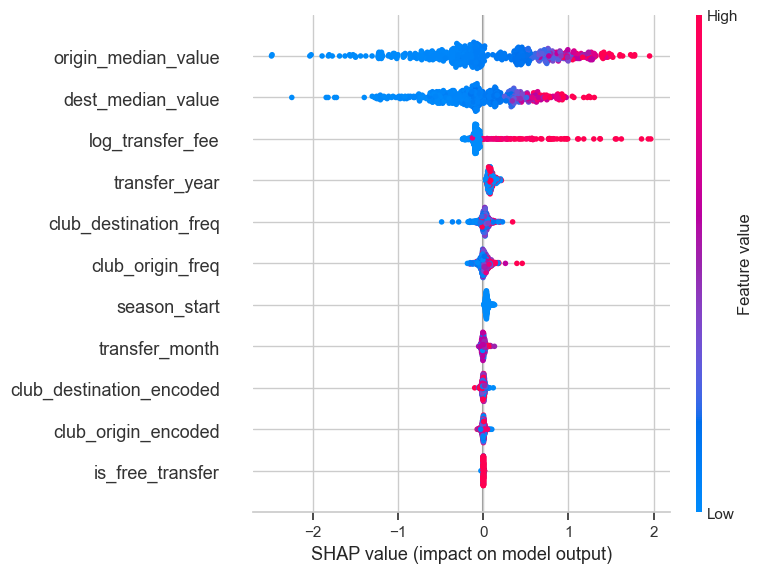

In [34]:
# Beeswarm — dirección e intensidad del impacto por feature
shap.summary_plot(
    shap_values, X_test_sample,
    feature_names=FEATURES,
    show=True
)

## 10. Visualización del Árbol de Decisión

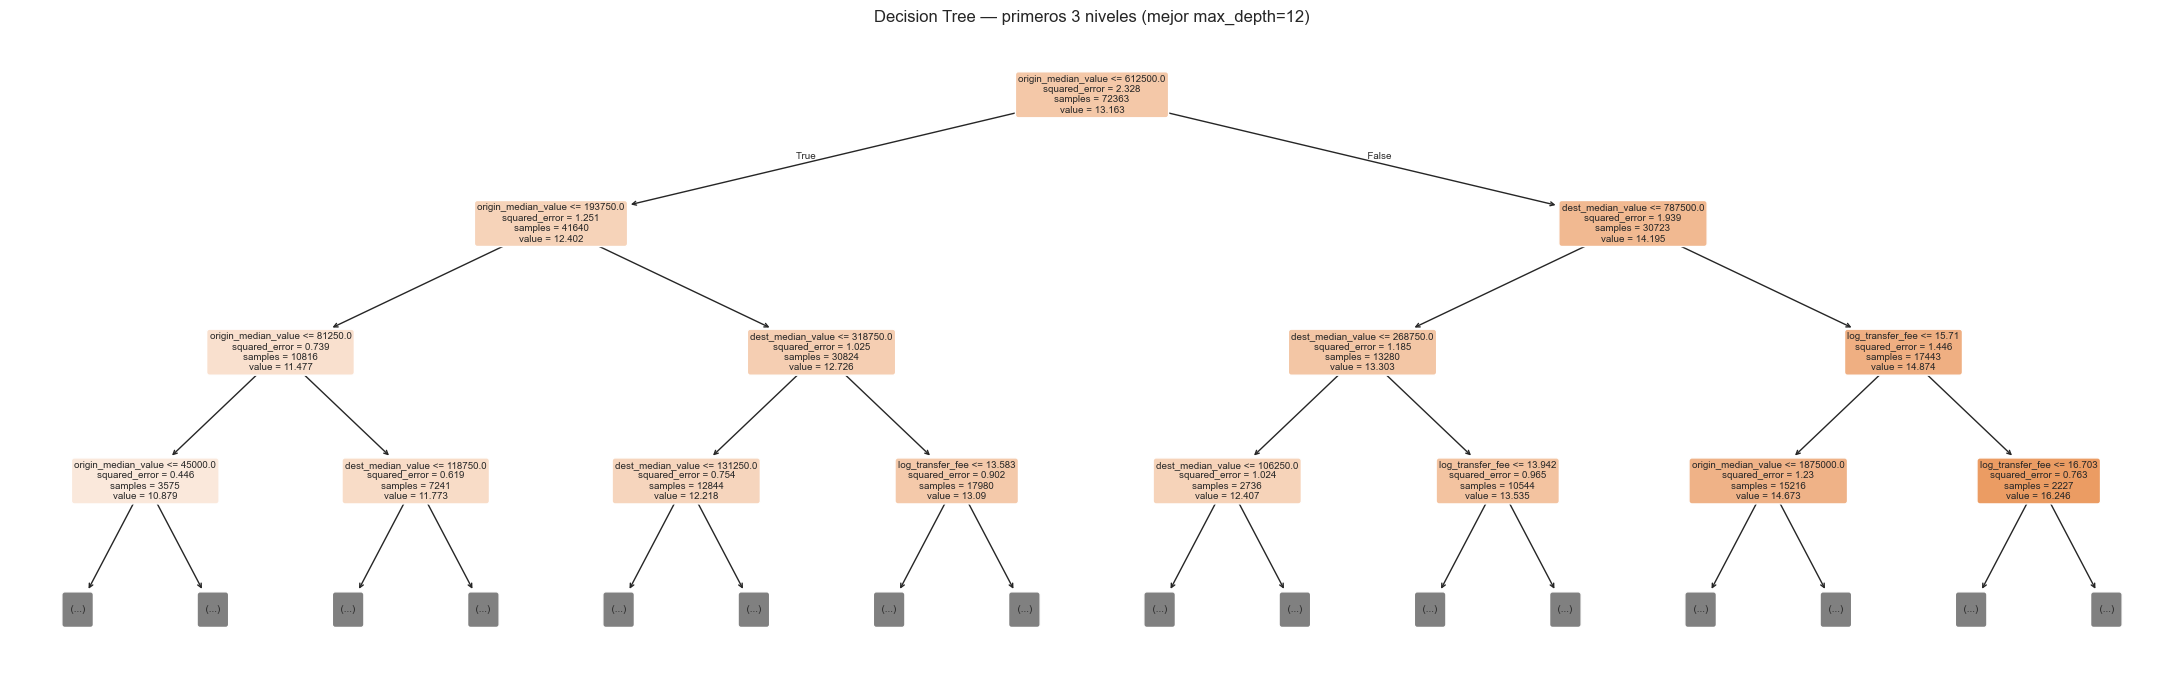

In [35]:
plt.figure(figsize=(22, 7))
plot_tree(
    dt, max_depth=3,
    feature_names=FEATURES,
    filled=True, fontsize=7, rounded=True
)
plt.title(f"Decision Tree — primeros 3 niveles (mejor max_depth={best_depth})")
plt.tight_layout()
plt.show()

# Usando otras variables

## Cargar los otros archivos disponibles

In [37]:
players = pd.read_csv("players.csv")
print("players.csv:", players.shape)
print(players.columns.tolist())

players.csv: (47702, 26)
['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'international_caps', 'international_goals', 'current_national_team_id', 'url', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur']


In [38]:
appearances = pd.read_csv("appearances.csv")
print("appearances.csv:", appearances.shape)
print(appearances.columns.tolist())

appearances.csv: (1862208, 13)
['appearance_id', 'game_id', 'player_id', 'player_club_id', 'player_current_club_id', 'date', 'player_name', 'competition_id', 'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played']


In [39]:
clubs = pd.read_csv("clubs.csv")
print("clubs.csv:", clubs.shape)
print(clubs.columns.tolist())

clubs.csv: (796, 17)
['club_id', 'club_code', 'name', 'domestic_competition_id', 'total_market_value', 'squad_size', 'average_age', 'foreigners_number', 'foreigners_percentage', 'national_team_players', 'stadium_name', 'stadium_seats', 'net_transfer_record', 'coach_name', 'last_season', 'filename', 'url']


## Enriquecer con features del jugador

In [40]:
# Features del jugador: edad, posición, pie hábil, altura
player_features = players[[
    "player_id", "date_of_birth", "position",
    "sub_position", "foot", "height_in_cm",
    "highest_market_value_in_eur", "country_of_citizenship"
]].copy()

# Calcular edad al momento de la transferencia
df_clean["transfer_date"] = pd.to_datetime(df_clean["transfer_date"], errors="coerce")
df_clean = df_clean.merge(player_features, on="player_id", how="left")

df_clean["date_of_birth"] = pd.to_datetime(df_clean["date_of_birth"], errors="coerce")
df_clean["age_at_transfer"] = (
    (df_clean["transfer_date"] - df_clean["date_of_birth"]).dt.days / 365.25
)

# Curva no lineal de edad (U invertida documentada en literatura)
df_clean["age_squared"] = df_clean["age_at_transfer"] ** 2

print("Nulos en age_at_transfer:", df_clean["age_at_transfer"].isna().sum())
print(df_clean["position"].value_counts())

Nulos en age_at_transfer: 13
position
Attack        29810
Defender      29746
Midfield      26172
Goalkeeper    10595
Missing          15
Name: count, dtype: int64


## Encoding de variables categóricas del jugador

In [41]:
# Posición
pos_dummies = pd.get_dummies(df_clean["position"], prefix="pos", dummy_na=True)
df_clean = pd.concat([df_clean, pos_dummies], axis=1)
pos_cols = pos_dummies.columns.tolist()

# Pie hábil
foot_dummies = pd.get_dummies(df_clean["foot"], prefix="foot", dummy_na=True)
df_clean = pd.concat([df_clean, foot_dummies], axis=1)
foot_cols = foot_dummies.columns.tolist()

# Altura: imputar con mediana
df_clean["height_in_cm"] = df_clean["height_in_cm"].fillna(df_clean["height_in_cm"].median())

# Log del mayor valor histórico del jugador (muy predictivo)
df_clean["log_highest_market_value"] = np.log1p(
    df_clean["highest_market_value_in_eur"].fillna(0)
)

print("Features de jugador agregadas:", pos_cols + foot_cols)

Features de jugador agregadas: ['pos_Attack', 'pos_Defender', 'pos_Goalkeeper', 'pos_Midfield', 'pos_Missing', 'pos_nan', 'foot_both', 'foot_left', 'foot_right', 'foot_nan']


## Enriquecer con estadísticas de apariciones

In [42]:
player_stats = appearances.groupby("player_id").agg(
    total_appearances = ("appearance_id", "count"),
    total_goals       = ("goals", "sum"),
    total_assists     = ("assists", "sum"),
    total_minutes     = ("minutes_played", "sum"),
    avg_goals         = ("goals", "mean"),
    avg_assists       = ("assists", "mean"),
).reset_index()

df_clean = df_clean.merge(player_stats, on="player_id", how="left")

# Imputar con 0 los jugadores sin apariciones registradas
stats_cols = ["total_appearances", "total_goals", "total_assists",
              "total_minutes", "avg_goals", "avg_assists"]
df_clean[stats_cols] = df_clean[stats_cols].fillna(0)

print(df_clean[stats_cols].describe())

       total_appearances   total_goals  total_assists  total_minutes  \
count       96338.000000  96338.000000   96338.000000   96338.000000   
mean           80.793384      8.827514       6.399396    5497.590307   
std           105.832962     21.939464      13.735690    7728.290966   
min             0.000000      0.000000       0.000000       0.000000   
25%             0.000000      0.000000       0.000000       0.000000   
50%            33.000000      1.000000       1.000000    1904.000000   
75%           126.000000      7.000000       6.000000    8303.000000   
max           656.000000    525.000000     224.000000   53667.000000   

          avg_goals   avg_assists  
count  96338.000000  96338.000000  
mean       0.060476      0.043232  
std        0.096619      0.062458  
min        0.000000      0.000000  
25%        0.000000      0.000000  
50%        0.014286      0.012579  
75%        0.086957      0.072848  
max        2.000000      1.000000  


## Actualizar FEATURES y reentrenar 

In [43]:
FEATURES = [
    # Transaccionales originales
    "transfer_year", "transfer_month", "season_start",
    "is_free_transfer", "log_transfer_fee",
    "club_origin_encoded", "club_destination_encoded",
    "club_origin_freq", "club_destination_freq",
    "origin_median_value", "dest_median_value",
    # Jugador
    "age_at_transfer", "age_squared",
    "height_in_cm", "log_highest_market_value",
    # Rendimiento
    "total_appearances", "total_goals", "total_assists",
    "total_minutes", "avg_goals", "avg_assists",
] + pos_cols + foot_cols

# Recrear splits
mask_test  = df_clean["transfer_season"] == "24/25"
mask_val   = df_clean["transfer_season"] == "23/24"
mask_train = ~mask_test & ~mask_val

train = df_clean[mask_train].copy()
val   = df_clean[mask_val].copy()
test  = df_clean[mask_test].copy()

# Recalcular target encodings con train
global_median = train["market_value_in_eur"].median()
median_origin = train.groupby("from_club_name")["market_value_in_eur"].median().to_dict()
median_dest   = train.groupby("to_club_name")["market_value_in_eur"].median().to_dict()

for split in [train, val, test]:
    split["origin_median_value"] = split["from_club_name"].map(median_origin).fillna(global_median)
    split["dest_median_value"]   = split["to_club_name"].map(median_dest).fillna(global_median)

X_train = train[FEATURES]
X_val   = val[FEATURES]
X_test  = test[FEATURES]

imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=FEATURES)
X_val   = pd.DataFrame(imputer.transform(X_val),       columns=FEATURES)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=FEATURES)

y_train     = train[TARGET_LOG].reset_index(drop=True)
y_val_log   = val[TARGET_LOG].reset_index(drop=True)
y_val_orig  = val[TARGET_ORIG].reset_index(drop=True)
y_test_log  = test[TARGET_LOG].reset_index(drop=True)
y_test_orig = test[TARGET_ORIG].reset_index(drop=True)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Total features: {len(FEATURES)}")

Train: (72363, 31) | Val: (11962, 31) | Test: (12013, 31)
Total features: 31


## Reentrenar todos los modelos

In [44]:
# Regresión Lineal
lr = LinearRegression()
lr.fit(X_train, y_train)
res_lr_val = evaluate_model("Regresión Lineal", lr, split="val")


Modelo : Regresión Lineal  |  Split: VAL
log-RMSE : 0.7561
R²       : 0.7423
MAE (€)  : 1,259,359


In [45]:
# Decision Tree
best_r2, best_depth, best_dt = -np.inf, None, None
for depth in [4, 6, 8, 10, 12]:
    dt_c = DecisionTreeRegressor(max_depth=depth, min_samples_leaf=20, random_state=42)
    dt_c.fit(X_train, y_train)
    r2_v = r2_score(y_val_log, dt_c.predict(X_val))
    print(f"  max_depth={depth}  →  R²_val={r2_v:.4f}")
    if r2_v > best_r2:
        best_r2, best_depth, best_dt = r2_v, depth, dt_c

print(f"\nMejor max_depth: {best_depth}")
dt = best_dt
res_dt_val = evaluate_model("Decision Tree", dt, split="val")

  max_depth=4  →  R²_val=0.6289
  max_depth=6  →  R²_val=0.7040
  max_depth=8  →  R²_val=0.7297
  max_depth=10  →  R²_val=0.7388
  max_depth=12  →  R²_val=0.7437

Mejor max_depth: 12

Modelo : Decision Tree  |  Split: VAL
log-RMSE : 0.7539
R²       : 0.7437
MAE (€)  : 875,603


In [46]:
# Random Forest
best_r2_rf, best_params, best_rf = -np.inf, {}, None
for n_est in [100, 200]:
    for depth in [8, 12, 16, None]:
        rf_c = RandomForestRegressor(
            n_estimators=n_est, max_depth=depth,
            min_samples_leaf=10, n_jobs=-1, random_state=42
        )
        rf_c.fit(X_train, y_train)
        r2_v = r2_score(y_val_log, rf_c.predict(X_val))
        print(f"  n_est={n_est}  max_depth={depth}  →  R²_val={r2_v:.4f}")
        if r2_v > best_r2_rf:
            best_r2_rf  = r2_v
            best_params = {"n_estimators": n_est, "max_depth": depth}
            best_rf     = rf_c

print(f"\nMejores parámetros RF: {best_params}")
rf = best_rf
res_rf_val = evaluate_model("Random Forest", rf, split="val")

  n_est=100  max_depth=8  →  R²_val=0.7561
  n_est=100  max_depth=12  →  R²_val=0.7780
  n_est=100  max_depth=16  →  R²_val=0.7837
  n_est=100  max_depth=None  →  R²_val=0.7846
  n_est=200  max_depth=8  →  R²_val=0.7563
  n_est=200  max_depth=12  →  R²_val=0.7786
  n_est=200  max_depth=16  →  R²_val=0.7845
  n_est=200  max_depth=None  →  R²_val=0.7853

Mejores parámetros RF: {'n_estimators': 200, 'max_depth': None}

Modelo : Random Forest  |  Split: VAL
log-RMSE : 0.6901
R²       : 0.7853
MAE (€)  : 784,302


## Comparar modelos


Modelo : Regresión Lineal  |  Split: TEST
log-RMSE : 0.7143
R²       : 0.7538
MAE (€)  : 1,238,919

Modelo : Decision Tree  |  Split: TEST
log-RMSE : 0.6864
R²       : 0.7727
MAE (€)  : 905,413

Modelo : Random Forest  |  Split: TEST
log-RMSE : 0.6148
R²       : 0.8176
MAE (€)  : 801,756

=== Validación ===
           model split  log_RMSE       R2      MAE_eur
Regresión Lineal   val  0.756052 0.742290 1.259359e+06
   Decision Tree   val  0.753919 0.743742 8.756035e+05
   Random Forest   val  0.690053 0.785320 7.843017e+05

=== Test ===
           model split  log_RMSE       R2      MAE_eur
Regresión Lineal  test  0.714254 0.753839 1.238919e+06
   Decision Tree  test  0.686361 0.772690 9.054128e+05
   Random Forest  test  0.614751 0.817647 8.017564e+05


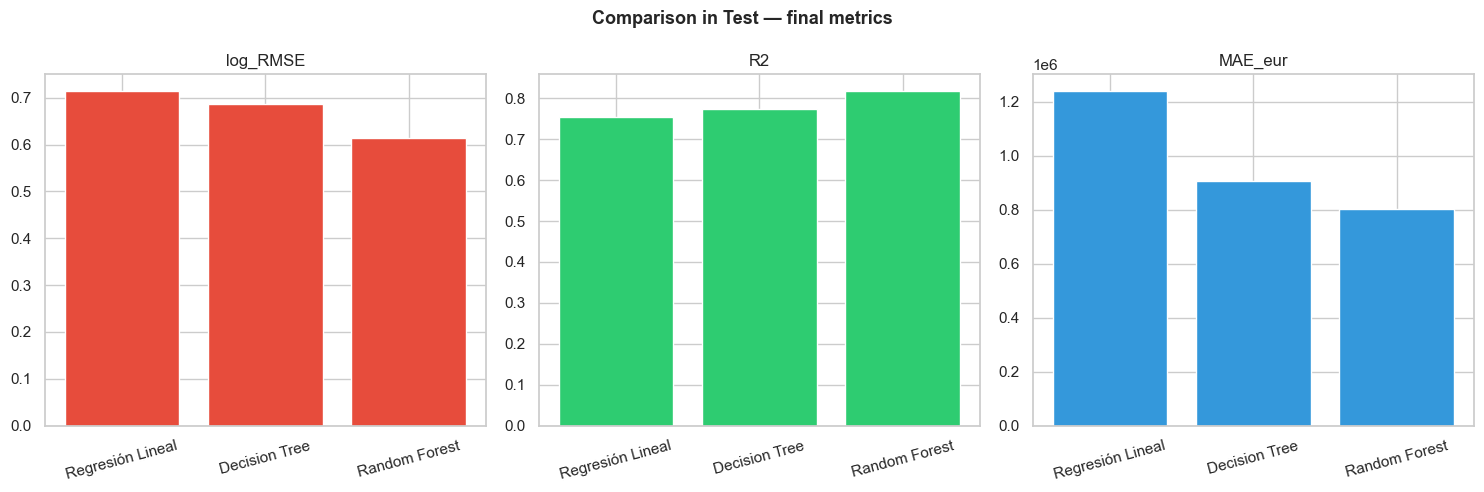

In [50]:
# Evaluación final en TEST
res_lr_test = evaluate_model("Regresión Lineal", lr, split="test")
res_dt_test = evaluate_model("Decision Tree",    dt, split="test")
res_rf_test = evaluate_model("Random Forest",    rf, split="test")

# Tabla comparativa
results_df = pd.DataFrame([
    res_lr_val, res_dt_val, res_rf_val,
    res_lr_test, res_dt_test, res_rf_test
])

print("\n=== Validación ===")
print(results_df[results_df["split"] == "val"].to_string(index=False))
print("\n=== Test ===")
print(results_df[results_df["split"] == "test"].to_string(index=False))

# Gráfico comparativo en Test
test_results = results_df[results_df["split"] == "test"].reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ["log_RMSE", "R2", "MAE_eur"]
colors  = ["#e74c3c", "#2ecc71", "#3498db"]

for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(test_results["model"], test_results[metric], color=color)
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Comparison in Test — final metrics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Analisis de Predicciones vs Valores Reales

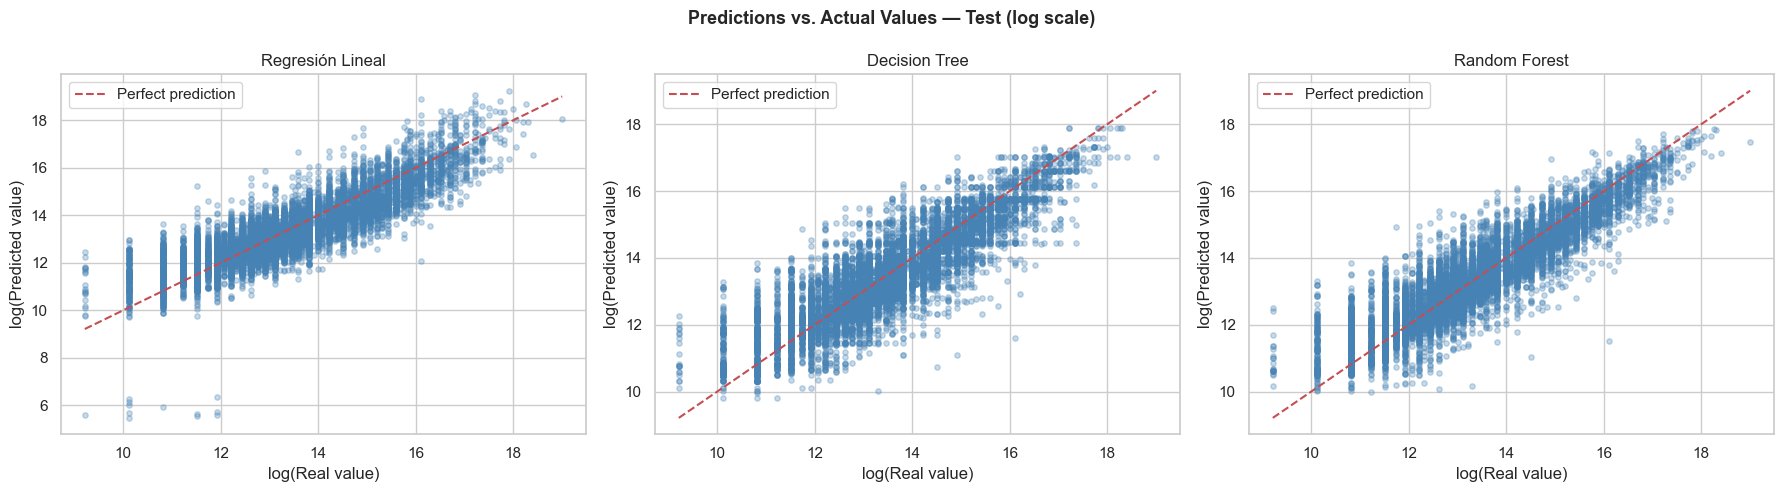

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos = [
    ("Regresión Lineal", lr),
    ("Decision Tree",    dt),
    ("Random Forest",    rf)
]

for ax, (name, model) in zip(axes, modelos):
    y_pred = model.predict(X_test)
    ax.scatter(y_test_log, y_pred, alpha=0.3, s=15, color="steelblue")
    lims = [y_test_log.min(), y_test_log.max()]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
    ax.set_xlabel("log(Real value)")
    ax.set_ylabel("log(Predicted value)")
    ax.set_title(name)
    ax.legend()

plt.suptitle("Predictions vs. Actual Values — Test (log scale)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

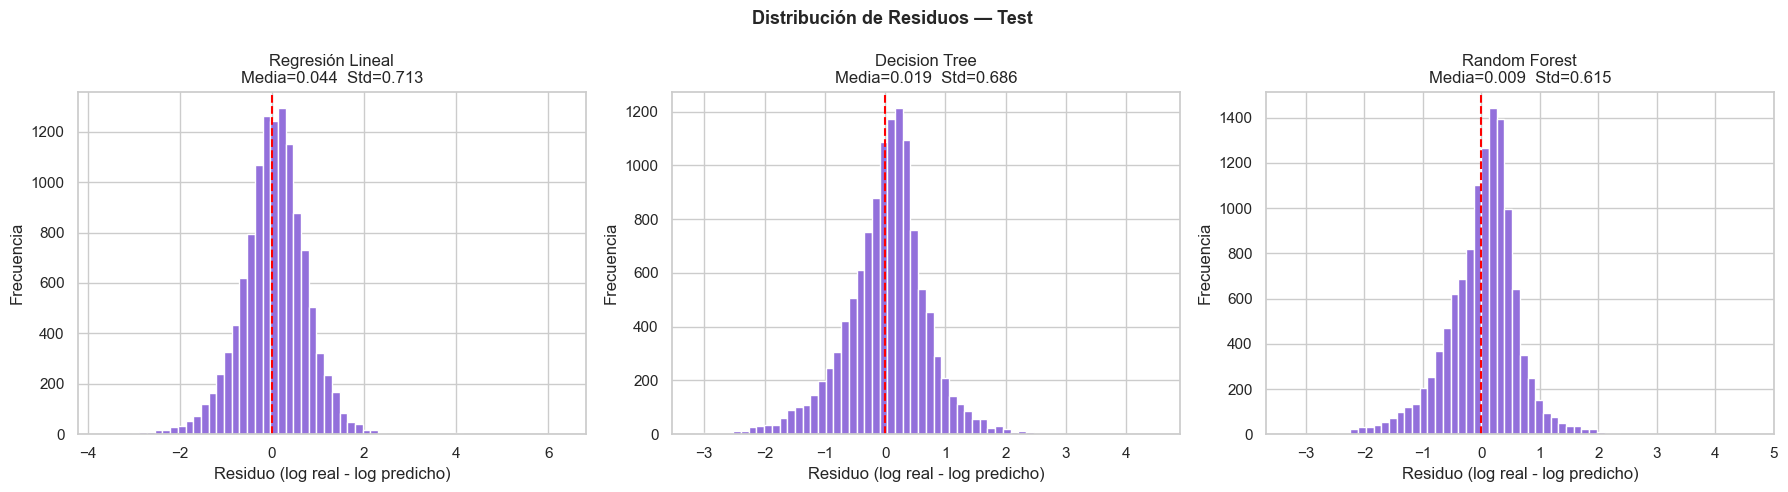

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, modelos):
    y_pred  = model.predict(X_test)
    residuos = y_test_log - y_pred
    ax.hist(residuos, bins=60, color="mediumpurple", edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_xlabel("Residuo (log real - log predicho)")
    ax.set_ylabel("Frecuencia")
    ax.set_title(f"{name}\nMedia={residuos.mean():.3f}  Std={residuos.std():.3f}")

plt.suptitle("Distribución de Residuos — Test", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()